In [1]:
from pathlib import Path
import os
import json
import pandas as pd
from typing import Any
from kibad_llm.config import PROJ_ROOT
import matplotlib.pyplot as plt

# swith to project root to use same paths as in commands
os.chdir(PROJ_ROOT)
# set wider column width for displaying pandas data frames
pd.set_option("max_colwidth", 400)

2026-01-09 11:25:18.866 | INFO     | kibad_llm.config:<module>:11 - PROJ_ROOT path is: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm


In [2]:
EVALUATE_DIR = 'data/prediction_results/159_core_schema_baseline_multirun/logs/evaluate'

In [3]:
# load evaluation job_return_value.json files
def _load_evaluations(parent_dir: Path) -> dict:
    log_filename = 'job_return_value.json'
    # get sub directories, 1 level only
    run_dirs = [p for p in Path(parent_dir).iterdir() if p.is_dir()]
    # assume that each subdir contains a 'job_return_value.json' from a multi-run evaluation
    # (i.e. it contains a parent key indictating the run, may be empty, and sub-keys 'prediction' and 'overrides' that store metadata)
    data = [json.loads((subdir / log_filename).read_text()) for subdir in run_dirs]
    # keep the keys / identifiers?
    #runs = {key: subdict for d in data for key, subdict in d.items()}
    runs = [subdict for d in data for subdict in d.values()]
    return runs

eval_runs = _load_evaluations(EVALUATE_DIR)


In [4]:
# simplify the dictionaries and add group keys
def _flatten_dict(d: dict[str, Any], sep: str = ".") -> dict[str, Any]:
    result: dict[str, Any] = dict()
    for k, v in d.items():
        if isinstance(v, dict):
            for e in v:
                result[f"{k}{sep}{e}"] = (v[e])
    return result

def _clean_metadata(run_dict: dict) -> (dict, dict):
    metadata_keys = ['prediction', 'overrides']
    metadata = {}
    for k in metadata_keys:
        metadata[k] = run_dict.pop(k)

    return _flatten_dict(run_dict), _flatten_dict(metadata)

metrics, metadata = map(list, zip(*[_clean_metadata(run) for run in eval_runs]))

In [5]:
metrics_df = pd.DataFrame.from_records(metrics)

In [6]:
# add some metadata keys
metrics_df["overrides.pdf_directory"] = [str(m["overrides.pdf_directory"]) for m in metadata]
metrics_df["overrides.extractor/llm"] = [str(m.get("overrides.extractor/llm", "gpt_oss_20b")) for m in metadata] # may not be set for default gpt_oss_20b
metrics_df["overrides.experiment/predict"] = [str(m["overrides.experiment/predict"]) for m in metadata]
#metrics_df["overrides.request_parameters.extra_body.seed"] = [str(m["overrides.request_parameters.extra_body.seed"]) for m in metadata]

In [7]:
metrics_df_avg = metrics_df.groupby("overrides.extractor/llm", as_index=False).agg({col: 'first' if metrics_df[col].dtype == 'object' else 'mean' for col in metrics_df.columns})
metrics_df_avg

,biodiversity_level.precision,biodiversity_level.recall,biodiversity_level.f1,biodiversity_level.support,ecosystem_type.term.precision,ecosystem_type.term.recall,ecosystem_type.term.f1,ecosystem_type.term.support,habitat.precision,habitat.recall,...,AVG.recall,AVG.f1,AVG.support,ALL.precision,ALL.recall,ALL.f1,ALL.support,overrides.pdf_directory,overrides.extractor/llm,overrides.experiment/predict
0,0.253012,0.313433,0.280000,67.0,0.113772,0.358491,0.172727,53.0,0.521739,0.434783,...,0.301845,0.271163,132.0,0.211577,0.267677,0.236343,792.0,/ds/text/kiba-d/dev-set-100,gemma3_27b,faktencheck_core_fields_schema
1,0.297558,0.427861,0.350999,67.0,0.212816,0.333333,0.259760,53.0,0.593137,0.429952,...,0.352031,0.316506,132.0,0.236680,0.319024,0.271501,792.0,/ds/text/kiba-d/dev-set-100,gpt_oss_20b,faktencheck_core_fields_schema
2,0.000000,0.000000,0.000000,67.0,0.000000,0.000000,0.000000,53.0,0.000000,0.000000,...,0.000000,0.000000,132.0,0.000000,0.000000,0.000000,792.0,/ds/text/kiba-d/dev-set-100,ministral_3_14b,faktencheck_core_fields_schema
3,0.206349,0.388060,0.269430,67.0,0.071599,0.566038,0.127119,53.0,0.648649,0.521739,...,0.398373,0.258453,132.0,0.120508,0.347222,0.178920,792.0,/ds/text/kiba-d/dev-set-100,mistral_small_3_24b,faktencheck_core_fields_schema
4,0.142857,0.208955,0.169697,67.0,0.104348,0.226415,0.142857,53.0,0.456790,0.268116,...,0.236813,0.223624,132.0,0.197814,0.228535,0.212068,792.0,/ds/text/kiba-d/dev-set-100,nemotron_nano_12b,faktencheck_core_fields_schema
5,0.226667,0.253731,0.239437,67.0,0.291139,0.433962,0.348485,53.0,0.786667,0.427536,...,0.299111,0.316765,132.0,0.319422,0.251263,0.281272,792.0,/ds/text/kiba-d/dev-set-100,qwen3_30b,faktencheck_core_fields_schema


<Axes: xlabel='overrides.extractor/llm'>

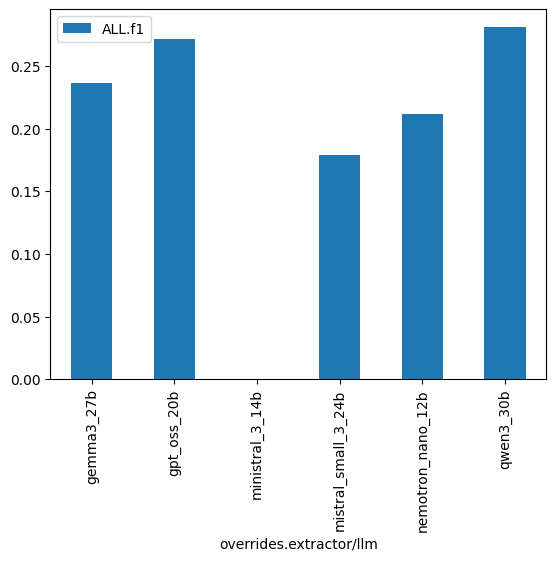

In [8]:
cols_to_plot = [col for col in metrics_df_avg.columns if col == 'ALL.f1']
metrics_df_avg.plot(kind="bar", x="overrides.extractor/llm", y=cols_to_plot)

<Axes: xlabel='overrides.extractor/llm'>

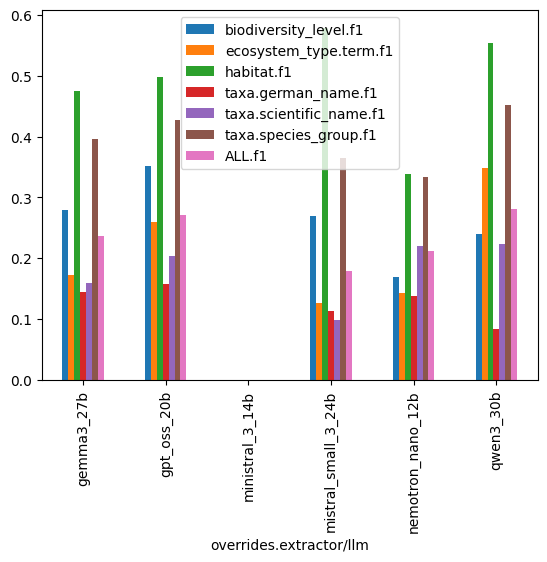

In [9]:
cols_to_plot = [col for col in metrics_df_avg.columns if col.endswith("f1") and not col.startswith("AVG")]
metrics_df_avg.plot(kind="bar", x="overrides.extractor/llm", y=cols_to_plot)